# Final Project Step 3: Conduct Statistical Analysis

<font size='4'>
    
Madelyn Carlson <br>
December 5 <br>
BIOS-584 <br>

<font size='4'>
Part 1: Aims <br>

**Aim 1:** Preprocess a subset of US-based Google and Reddit data. I will tokenize posts/queries, create a tokenization dictionary, and apply the NLP Bag of Words (BoW) technique to produce multiple lists of unique words from selected subreddits and Google searches. Then, I’ll review these lists manually to identify all terms related to PrEP, including PrEP-related jargon and synonyms for PrEP and its various brand names. The list of PrEP terms will serve as the first iteration of my PrEP-related lexicon (see the Final Project Step 1 assignment for more details on the PrEP-related lexicon). For Aim 1, the research question I want to answer is: What terminology does the general public use to refer to PrEP? What jargon and synonyms do people use for PrEP? 

**Aim 2:** Quantify the terms the general public uses to refer to PrEP on Google and Reddit, and generate descriptive statistics on their frequency of use.

**Aim 3:** Assess the proportion of terms the general public uses for PrEP that are appropriate versus those that are not. I will refer to the CDC PrEP Guidelines to determine which terms are appropriate and which are not.

<font size='4'>
Part 2: Analysis <br>

**Analysis Plan for Aim 1:** I will preprocess a subset of US-based Google and Reddit data. Specifically, I’ll tokenize posts/queries from one subreddit (r/prep) and 1 year of Google search query data (2024). Step 1 is to tokenize posts from subreddit titles, body content, replies, and Google searches by converting the data to lowercase and removing empty strings, stopwords, numbers, punctuation, and other symbols. Then, I can combine “toks” from the titles and posts into a tokenization dictionary that eliminates duplicate words while preserving the sequence of words for each post. The NLP Bag of Words (BoW) technique will treat these datasets as “bags” of words, resulting in multiple lists of unique words from selected subreddits and Google search queries. I’ll manually review these lists to flag and pull out all terms synonymous with PrEP, including PrEP-related jargon, synonyms, and misspellings of PrEP and its various brand names. By the end of Aim 1, I will produce a list of PrEP-related terms from r/prep and 2024 Google search queries. This manually curated list will become the first iteration of my PrEP-related lexicon. For more details on the PrEP-related lexicon, see the Final Project Step 1 assignment

In [80]:
#The following Python packages are required to preprocess the data 
import nltk
from nltk.tokenize import PunktTokenizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import sys
import csv
import nltk
import re
import pandas as pd
from datetime import datetime
import subprocess
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import PyPDF2
import seaborn as sns
from scipy.stats import chi2_contingency

In [81]:
# works to filter out from the source
stop_words = set(nltk.corpus.stopwords.words('english'))\
    .union(set(line.strip() for line in open('/Users/madelyncarlson/Library/CloudStorage/OneDrive-EmoryUniversity/Documents/Dissertation/PrEP_related/local_stop_words.txt')))

# list of regular expressions identifying stop-words
stop_patterns = [ re.compile(p) for p in [
    r"^$", # empty string
    r"\d+", # number-only 
    r"\w?\'\w+", # optional single letter followed by apostrophy+letters - typically "n't"
    r"^[!\"#$%&'()*+,-./:;<=>?@\[\]^_~’`\|…\‘\“\”–—]+$", # punctualtion-only
    r"^\w+=\w+$" # url paramaters like "size=100"
]]
# I created this negative filter list while reviewing the toks 
negative_filter = set(line.strip() for line in open('/Users/madelyncarlson/Library/CloudStorage/OneDrive-EmoryUniversity/Documents/Dissertation/PrEP_related/negative_filter.txt'))

# reddit CSV assumed data format:
# 0 - 'UNK'
# 1 - 'author'
# 2 - 'text' -- appears to be empty
# 3 - 'post_id'
# 4 - 'subreddit'
# 5 - 'title'
# 6 - 'selftext'
# 7 - 'created_at' (rfc3339)
# 8 - 'created_utc' (seconds after epoch)
# 9 - 'score'
# 10 - 'upvote_ratio'
# 11 - 'flair'

##
# output columns are:
# 0 - 'post_id'
# 1 - 'author'
# 2 - 'subreddit'
# 3 - created year
# 4 - 'created_at' (rfc3339)
# 5 - 'created_utc' (seconds after epoch)
# 6 - timezone offset
# 7 - 'score'
# 8 - 'upvote_ratio'
# 7 - bag of words - space-delimited
# 8 - 'title'
# 9 - 'text'

reader = csv.reader(sys.stdin)
writer = csv.writer(sys.stdout)
seen_messages = set()
for row in reader:
    # empty input
    if len(row) == 0: continue

    # any deleted message
    if row[1] == "[deleted]" or row[5] == "[deleted by user]" or row[6] == "[removed]": continue

    # included to remove duplicate messages
    if row[3] in seen_messages: continue
    seen_messages.add(row[3])

    ## Note: tokenization fails for no space after sentence period and next word. Should investigate.
    ## also, words with "/" between with no spaces treated as one word.
    title_toks = [w.lower() for w in nltk.tokenize.word_tokenize(row[5])]
    body_toks = [w.lower() for w in nltk.tokenize.word_tokenize(row[6])]
    # combine title and body toks into a dict to remove duplicates yet maintain ordering
    toks = [ w for w in (dict.fromkeys(title_toks) | dict.fromkeys(body_toks)).keys() 
             if (w not in stop_words and not(any([p.match(w) for p in stop_patterns]))) ]

    row[8] = int(float(row[8])) if row[8] else row[8]
    created_at_utc = datetime.fromtimestamp(row[8]) if row[8] else None
    created_at_local = datetime.strptime(row[7], "%Y-%m-%d %H:%M:%S") if row[7] else None
    year = created_at_utc.year if created_at_utc else (
        created_at_local.year if created_at_local else "")
    local_time_offset = created_at_local - created_at_utc if created_at_utc and created_at_local else None
    
    # output if we have tokens and the message does not match a negative_filter word
    if len(toks) > 0 and not any([t in negative_filter for t in toks]):
        ## todo sort out time stuff
        out_row = [
            row[3], 
            row[1], 
            row[4], 
            year, 
            row[7], 
            row[8], 
            local_time_offset,
            row[9], 
            row[10], 
            " ".join(toks), 
            row[5], 
            row[6]
        ]
        writer.writerow(out_row)

I applied this to subset of Reddit data from r/prep 2024 (./process_reddit_output.py < prep_SR_data.csv | ./apply_positive_filter.py > prep_SR_match.csv) and produced a clean version of the data for Aim 2. This dataset now includes a new column, bag_of_words, that lists the prep-related terms from my positive filter list found in each Reddit post. I will use this data in Aim 2. 

**Aim 2:** Quantify the terms the general public uses to refer to PrEP on Google and Reddit, and generate descriptive statistics on their frequency of use.

In [45]:
path = "/Users/madelyncarlson/Library/CloudStorage/OneDrive-EmoryUniversity/Documents/Dissertation/PrEP_related/prep_SR_bow.csv"
columns = [
    'post_id',          # 0
    'author',           # 1
    'subreddit',        # 2
    'created_year',     # 3
    'created_at',       # 4
    'created_utc',      # 5
    'timezone_offset',  # 6
    'score',            # 7
    'upvote_ratio',     # 8
    'bag_of_words',     # 9
    'title',            # 10
    'text'              # 11
]

# Import CSV with no headers and assign column names
prep = pd.read_csv(path, header=None, names=columns)

# View first 5 rows to check
print(prep.head())

  post_id          author subreddit  created_year created_at  created_utc  \
0  1y7qer        calmacco      prep          2014        NaN   1392699268   
1  q1vmat    CoolbeansXVI      prep          2021        NaN   1633437882   
2  qk87fp  Nearby-Ear4166      prep          2021        NaN   1635748708   
3  vomt8x  Empty-Cost-712      prep          2022        NaN   1656633866   
4  vp2o7a  ichillonforums      prep          2022        NaN   1656687117   

  timezone_offset  score  upvote_ratio  \
0             NaN      1           NaN   
1             NaN      2          1.00   
2             NaN      6          1.00   
3             NaN      2          1.00   
4             NaN      4          0.84   

                                        bag_of_words  \
0                                               prep   
1                                               prep   
2               pep hiv test tested tests meds virus   
3                                            truvada   
4  p

In [58]:
# I created a postitive filter list by reviewing the toks from r/prep and pulling out every PrEP-related term
prep_terms = "/Users/madelyncarlson/Library/CloudStorage/OneDrive-EmoryUniversity/Documents/Dissertation/PrEP_related/positive_filter.txt"
with open(prep_terms, 'r') as f:
    positive_words = [line.strip().lower() for line in f if line.strip()]
print(positive_words[:100]) # check out the terms I added to the positive filter list 

# Initialize dictionary 
word_counts = {}

# Apply to the dataset and print 
for word in positive_words:
    word_counts[word] = prep['bag_of_words'].str.count(rf'\b{re.escape(word)}\b', flags=re.IGNORECASE).sum()
counts_prep = pd.DataFrame.from_dict(word_counts, orient='index', columns=['count'])
counts_prep['proportion'] = counts_prep['count'] / counts_prep['count'].sum() * 100
print() 
print(counts_prep.sort_values(by='count', ascending=False).head(20))

['alafenamide', 'aminotransferase', 'apretude', 'aspartate', 'atorvastatin', 'acriptega', 'apertude', 'apretude', 'apotex', 'avita', 'biktarvy', 'bottom-prep', 'cabotegravir', 'c-reactive', 'demand', 'detectable', 'detected', 'detection', 'descocy', 'descovy', 'disoproxil', 'disclose', 'discontinued', 'disoproxil-emtricitabine', 'disop', 'dolutegravir', 'dosage', 'dose', 'doses', 'dosing', 'dosis', 'doxicycline', 'drug', 'drugs', 'drugs.com', 'dynamix', 'emtricitabin/', 'emtricitabin', 'emtricitabin/tenofovirdisoproxil', 'emtricitabine', 'emtricitabine/tenof', 'emtrictabine', 'gilead', 'heymistr', 'hiv', 'hiv+', 'hptn', 'infect', 'infected', 'infection', 'infections', 'lamivudine', 'long-acting', 'long-term', 'med', 'medicated', 'medication', 'medications', 'medicine', 'medicines', 'meds', 'metformin', 'minoxidil', 'mistr', 'mistr.com', 'mylan', 'naproxen', 'on-demand', 'one-month', 'one-pill', 'optumrx', 'optum', 'poz', 'pep', 'pre', 'pre-exposure', 'prep', 'prep-like', 'prep-many', '

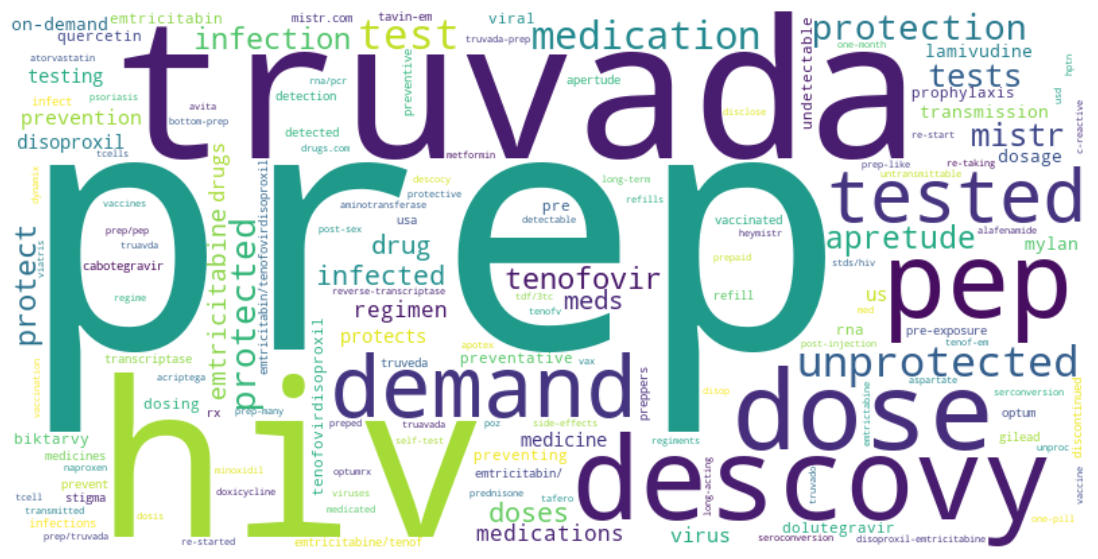

In [63]:
prep_wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis')\
            .generate_from_frequencies(counts_prep['count'].to_dict())

plt.figure(figsize=(15, 7))
plt.imshow(prep_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [72]:
# Upload a PDF of the CDC guidelines and see which counts_prep terms are in the PDF using 
# a boolean column in in_guideline 
guidelines = '/Users/madelyncarlson/Library/CloudStorage/OneDrive-EmoryUniversity/Documents/Dissertation/CDC_2021_HIV_Prep_Guideline.pdf'
with open(guidelines, 'rb') as f:
    reader = PyPDF2.PdfReader(f)
    text = ''
    for page in reader.pages:
        text += page.extract_text() + ' '
guideline_words = re.findall(r'\b\w+\b', text.lower())
# Convert into a set for faster lookup
guideline_set = set(guideline_words)
counts_prep['in_guideline'] = counts_prep.index.isin(guideline_set)
total_count = counts_prep['count'].sum()
counts_prep['proportion_in_guideline'] = counts_prep.apply(
    lambda row: (row['count'] / total_count) if row['in_guideline'] else 0, axis=1
)
total_terms = len(counts_prep)
terms_in_guideline = counts_prep['in_guideline'].sum()
print(f"Terms in guideline: {terms_in_guideline}/{total_terms} ({terms_in_guideline/total_terms*100:.2f}%)")

Terms in guideline: 65/157 (41.40%)


**Aim 3:** Assess the proportion of terms the general public uses for PrEP that are appropriate versus those that are not. I will refer to the CDC PrEP Guidelines to determine which terms are appropriate and which are not. My plan is to determine the proportions of terms from the Google and Reddit data that are included in the CDC PrEP Guidelines and those that are not. Next, I will find the union of terms in the (a) Google/Reddit and the (b) CDC Guidelines datasets. I'll compare the distribution of terms in the (a) Google/Reddit and the (b) CDC Guidelines. To assess the distribution of terms, I will produce density plots of the terms in (a) Google/Reddit and (b) CDC Guidelines, and I will run a chi-square test to assess differences in the distributions. Statistical significance can be assessed at α = 0.05 

So, 65 out of the 157 (41%) unique prep terms from Reddit data were in the guidelines. And 58.6% of the Reddit terms do not appear in the guideline. 

In [89]:
# Here are the terms that are in common: 
reddit_terms_set = set(counts_prep.index)
common_terms = reddit_terms_set.intersection(guideline_set)
print(sorted(common_terms))

['alafenamide', 'cabotegravir', 'demand', 'descovy', 'detectable', 'detected', 'detection', 'disclose', 'discontinued', 'disoproxil', 'dolutegravir', 'dosage', 'dose', 'doses', 'dosing', 'drug', 'drugs', 'emtricitabine', 'gilead', 'hiv', 'hptn', 'infect', 'infected', 'infection', 'infections', 'lamivudine', 'med', 'medication', 'medications', 'medicine', 'pep', 'pre', 'prep', 'prevent', 'preventing', 'prevention', 'preventive', 'prophylaxis', 'protect', 'protection', 'protective', 'refill', 'refills', 'regimen', 'rna', 'seroconversion', 'stigma', 'tenofovir', 'test', 'tested', 'testing', 'tests', 'transmission', 'transmitted', 'truvada', 'undetectable', 'untransmittable', 'us', 'usa', 'vaccinated', 'vaccine', 'vaccines', 'viral', 'virus', 'viruses']


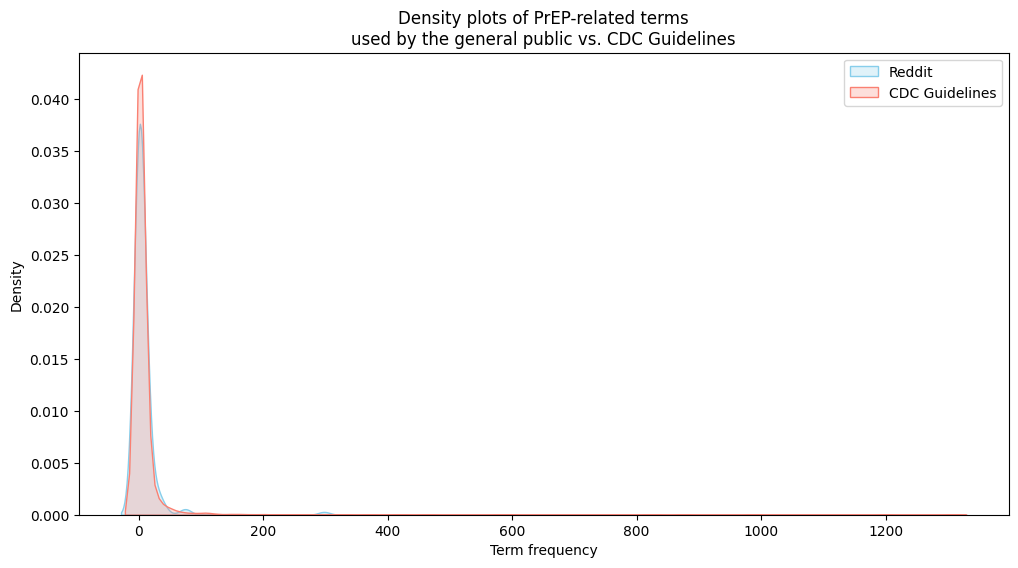

In [90]:
reddit_terms = counts_prep.copy()
reddit_terms = reddit_terms.rename(columns={'count':'frequency'})
reddit_terms['source'] = 'Reddit'  

guideline_counter = Counter(guideline_words)
guideline_terms = pd.DataFrame.from_dict(guideline_counter, orient='index', columns=['frequency'])
guideline_terms['source'] = 'CDC Guidelines'

all_terms = pd.concat([reddit_terms, guideline_terms])
all_terms['term'] = all_terms.index

# Plot
plt.figure(figsize=(12,6))
sns.kdeplot(
    data=all_terms[all_terms['source']=='Reddit'], 
    x='frequency', 
    fill=True, 
    label='Reddit', 
    color='skyblue'
)
sns.kdeplot(
    data=all_terms[all_terms['source']=='CDC Guidelines'], 
    x='frequency', 
    fill=True, 
    label='CDC Guidelines', 
    color='salmon'
)

plt.title('Density plots of PrEP-related terms\nused by the general public vs. CDC Guidelines')
plt.xlabel('Term frequency')
plt.ylabel('Density')
plt.legend()
plt.show()

In [88]:
# Next, run a chi-square test to assess differences in the distributions. Statistical significance can be assessed at α = 0.05
#all_terms_pivot = all_terms.pivot_table(
#    index='term', 
#    columns='source', 
#    values='frequency', 
#    fill_value=0
#)
#chi2, p_value, dof, expected = chi2_contingency(all_terms_pivot)

#print(f"Chi-square statistic: {chi2:.2f}")
#print(f"Degrees of freedom: {dof}")
#print(f"P-value: {p_value:.4f}")

#if p_value < 0.05:
#    print("Result: Significant difference in term distributions between Reddit and Guidelines")
#else:
#    print("Result: No significant difference in term distributions")

# I am running into an issue here... I am getting an error that chi2_contingency running on sparse term data. 
# The chi-square test requires that all expected frequencies be > 0, but in my case, some terms appear in only one source. 

# Okay... Next, I'll try keeping only terms that appear at least once in both sources
all_terms_pivot_filtered = all_terms_pivot[(all_terms_pivot > 0).all(axis=1)]
chi2, p_value, dof, expected = chi2_contingency(all_terms_pivot_filtered)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Significant difference in term distributions")
else:
    print("No significant difference in term distributions")

Chi-square statistic: 1240.97
Degrees of freedom: 64
P-value: 0.0000
Significant difference in term distributions


I need to think more about the Chi-square I've run and interpretation... will post an update/talk to you about it over email. 